# Channel Timing

This notebook shows the timing characteristics of a CDL channel model when applied to input signals over a duration of 100 slots.

In [1]:
import numpy as np
import scipy.io
import time
import matplotlib.pyplot as plt

from neoradium import Carrier, Modem, CdlChannel, AntennaPanel, Grid, Waveform, random
from neoradium.utils import getNmse, getMse


In [2]:
# Create a random grid and the corresponding transmit (TX) waveform
carrierFreq=4e9 # 4 GHz

carrier = Carrier(startRb=0, numRbs=24, spacing=30)     # Try other subcarrier spacing values
bwp = carrier.curBwp
print(bwp)

txGrid = bwp.createGrid(numPorts=8)                     # Create an empty resource grid (8 antenna ports)

stats = txGrid.getStats()                               # Get grid statistics
modem = Modem("16QAM")                                  # Create a Modulator/Demodulator object
numRandomBits = stats['UNASSIGNED']*modem.qm            # Calculate total number of bits available in the grid

bits = random.bits(numRandomBits)                       # Create random bits
symbols = modem.modulate(bits)                          # Modulate the bits to complex symbols

indexes = txGrid.getReIndexes("UNASSIGNED")             # Get indexes of "UNASSIGNED" REs in the grid
txGrid[indexes] = symbols                               # Set them to symbols

txWaveform = txGrid.ofdmModulate(carrierFreq)           # OFDM modulation: Grid -> Waveform
print("Shape of transmitted signal in time domain:",txWaveform.shape)


Bandwidth Part Properties:
  Resource Blocks:    24 RBs starting at 0 (288 subcarriers)
  Subcarrier Spacing: 30 kHz
  CP Type:            normal
  Interleaving:       No
  Bandwidth:          8.64 MHz
  symbolsPerSlot:     14
  slotsPerSubFrame:   2
  nFFT:               1024
  frameNo:            0
  slotNo:             0

Shape of transmitted signal in time domain: (8, 15360)


In [3]:
# Baseline performance (no channel, no noise): ofdmModulate → ofdmDemodulate
rxGridTD = txWaveform.ofdmDemodulate(bwp, f0=carrierFreq)
print(f"NMSE: {getNmse(txGrid.grid,rxGridTD.grid)}")
print(f"MAE: {np.abs(txGrid.grid-rxGridTD.grid).max()}")

NMSE: 3.952488193394566e-32
MAE: 7.108895957933346e-16


In [4]:
# Create a CDL-D channel model
channel = CdlChannel(bwp, 'D', delaySpread=300, carrierFreq=4e9, dopplerShift=15,
                     txAntenna = AntennaPanel([2,4], polarization="|"),  # 8 TX antenna
                     rxAntenna = AntennaPanel([1,2], polarization="|"),  # 2 RX antenna
                     seed = 1234)
channel


CDL-D Channel Properties:
  carrierFreq:              4 GHz
  normalizeGains:           True
  normalizeOutput:          True
  txDir:                    Downlink
  filterLen:                16 samples
  delayQuantSize:           64
  stopBandAtten:            80 dB
  dopplerShift:             15 Hz
  coherenceTime:            28.209 milliseconds
  delaySpread:              300 ns
  ueDirAZ:                  0°, 90°
  xPolPower:                11.00 dB
  angleSpreads:             5° 8° 3° 3°
  TX Antenna:
    Total Elements:         8
    spacing:                0.5𝜆, 0.5𝜆
    shape:                  2 rows x 4 columns
    polarization:           |
  RX Antenna:
    Total Elements:         2
    spacing:                0.5𝜆, 0.5𝜆
    shape:                  1 rows x 2 columns
    polarization:           |
    Orientation (𝛼,𝛃,𝛄):     180° 0° 0°
  hasLOS:                   True
  LOS Path:
    Delay (ns):             0.00000
    Power (dB):             -0.20000
    AOD (Deg):          

In [5]:
# Apply the channel in the time domain
maxDelay = channel.getMaxDelay()                         # Get maximum channel delay
paddedTxWaveform = txWaveform.pad(maxDelay)              # Pad the waveform with zeros
rxWaveform = channel.applyToSignal(paddedTxWaveform)     # Apply the channel to the waveform

syncedWaveform = rxWaveform.sync(channel.chanOffset)     # Synchronization
rxGridTd = syncedWaveform.ofdmDemodulate(bwp, f0=carrierFreq)

# Apply the channel in the frequency domain
chanMat = channel.getChannelMatrix()
rxGridFd = txGrid.applyChannel(chanMat)

# Compare time-domain vs. frequency-domain results
print(f"NMSE: {getNmse(rxGridFd.grid,rxGridTd.grid)}")


NMSE: 8.292828250427552e-06


In [6]:
# Apply the channel to 100 slots of the input signal
chanMats = []
for s in range(100):
    # Move to the next slot
    channel.goNext()

    txGrid = bwp.createGrid(numPorts=8)

    stats = txGrid.getStats()
    numRandomBits = stats['UNASSIGNED']*modem.qm
    bits = random.bits(numRandomBits)
    symbols = modem.modulate(bits)
    indexes = txGrid.getReIndexes("UNASSIGNED")
    txGrid[indexes] = symbols

    txWaveform = txGrid.ofdmModulate(carrierFreq)

    # Apply the channel in the time domain:
    maxDelay = channel.getMaxDelay()                            # Get maximum channel delay
    paddedTxWaveform = txWaveform.pad(maxDelay)                 # Pad the waveform with zeros
    rxWaveform = channel.applyToSignal(paddedTxWaveform)        # Apply the channel to the waveform

    syncedWaveform = rxWaveform.sync(channel.chanOffset)        # Synchronization
    rxGridTd = syncedWaveform.ofdmDemodulate(bwp, f0=carrierFreq)

    # Apply the channel in the frequency domain and compare results
    chanMat = channel.getChannelMatrix()
    rxGridFd = txGrid.applyChannel(chanMat)
    assert getNmse(rxGridFd.grid,rxGridTd.grid)<1e-3
    chanMats += [chanMat]


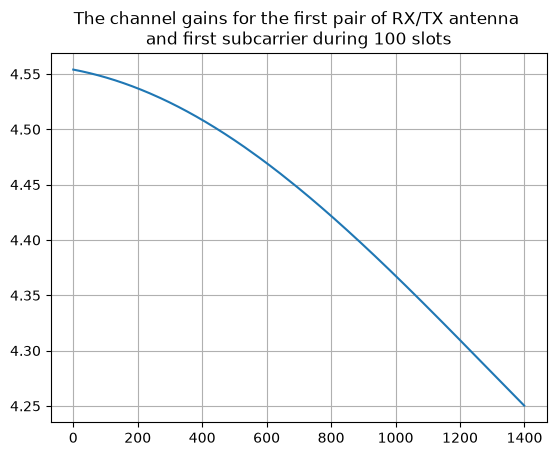

In [7]:
gs = np.concatenate([chanMat[:,0,0,0] for chanMat in chanMats])
plt.plot(np.abs(gs))
plt.title("The channel gains for the first pair of RX/TX antenna \n"+
          "and first subcarrier during 100 slots")
plt.grid()